In [7]:
!pip install numpy matplotlib scikit-fuzzy
!pip install scypy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.4 MB/s eta 0:00:00


10°C -> ventilador a 17%
20°C -> ventilador a 44%
25°C -> ventilador a 50%
30°C -> ventilador a 56%
38°C -> ventilador a 83%


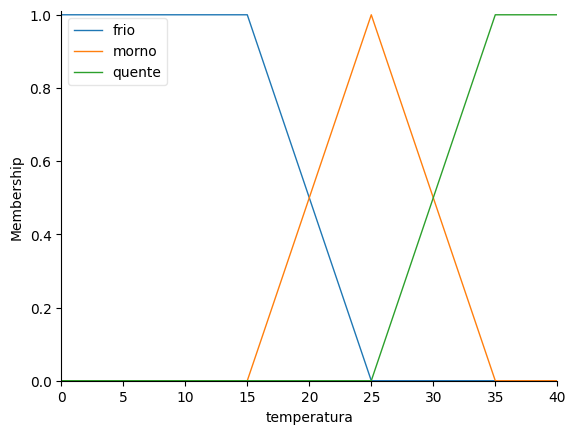

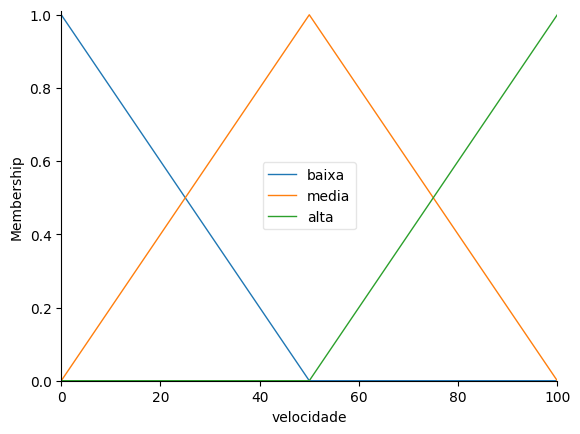

In [9]:
# ==============================================================================
# AULA 09 — SPRINT 1 (AC-3): MODELAGEM DAS VARIÁVEIS E CONJUNTO FUZZY
# Objetivo: Construir as Variáveis Linguísticas e Funções de Pertinência
# ==============================================================================

# Ventilador fuzzy com scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# 1) VARIÁVEIS: entrada (temperatura) e saída (velocidade do ventilador)
temperatura = ctrl.Antecedent(np.arange(0, 41, 1), "temperatura")
velocidade = ctrl.Consequent(np.arange(0, 101, 1), "velocidade")

# 2) CONJUNTOS FUZZY: formas (trapézios e triângulos) de cada categoria
#    trapmf = trapézio [a, b, c, d]   |   trimf = triângulo [a, b, c]
temperatura["frio"] = fuzz.trapmf(temperatura.universe, [0, 0, 15, 25])
temperatura["morno"] = fuzz.trimf(temperatura.universe, [15, 25, 35])
temperatura["quente"] = fuzz.trapmf(temperatura.universe, [25, 35, 40, 40])

velocidade["baixa"] = fuzz.trimf(velocidade.universe, [0, 0, 50])
velocidade["media"] = fuzz.trimf(velocidade.universe, [0, 50, 100])
velocidade["alta"] = fuzz.trimf(velocidade.universe, [50, 100, 100])

# 3) REGRAS: SE ... ENTÃO ...
regras = [
    ctrl.Rule(temperatura["frio"], velocidade["baixa"]),
    ctrl.Rule(temperatura["morno"], velocidade["media"]),
    ctrl.Rule(temperatura["quente"], velocidade["alta"]),
]

# 4) SISTEMA DE CONTROLE
sistema = ctrl.ControlSystem(regras)
ventilador = ctrl.ControlSystemSimulation(sistema)

# Testando com várias temperaturas
for temp in [10, 20, 25, 30, 38]:
    ventilador.input["temperatura"] = temp
    ventilador.compute()
    print(f"{temp}°C -> ventilador a {ventilador.output['velocidade']:.0f}%")

# 5) (Opcional) Desenhar os gráficos. Requer: pip install matplotlib
import matplotlib.pyplot as plt
temperatura.view()
velocidade.view()
plt.show()